<a href="https://colab.research.google.com/github/sagarkakkar03/Data-science/blob/main/HypothesisTesting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

In [4]:
df = pd.read_csv('50_Startups.csv')
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [ ]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [ ]:
df['R&D Spend'].corr(df['Profit'])

np.float64(0.9729004656594832)

<Axes: xlabel='R&D Spend', ylabel='Profit'>

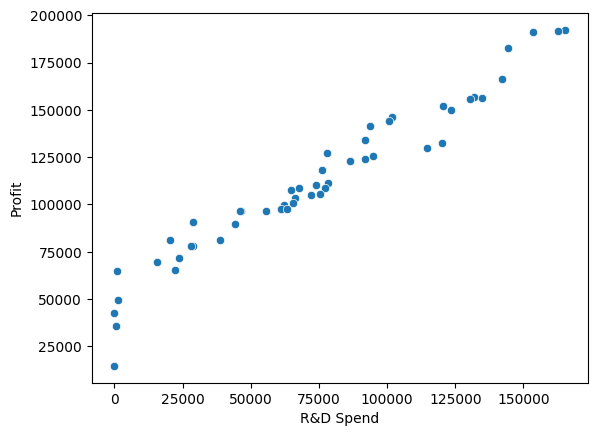

In [ ]:
sns.scatterplot(x = 'R&D Spend', y = 'Profit', data = df)

In [ ]:
df['Marketing Spend'].corr(df['Profit'])

np.float64(0.7477657217414767)

<Axes: xlabel='Marketing Spend', ylabel='Profit'>

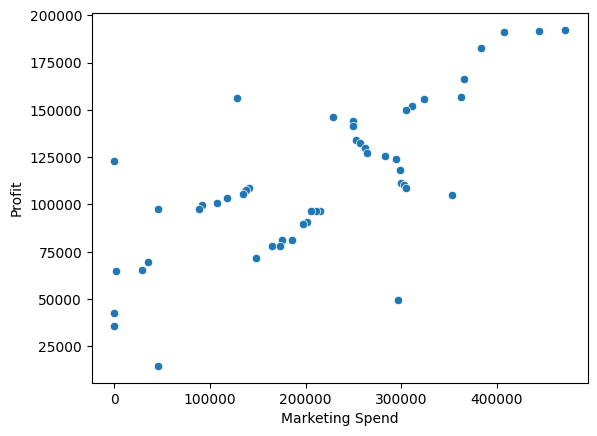

In [ ]:
sns.scatterplot(x='Marketing Spend', y='Profit', data=df)

In [ ]:
df['Administration'].corr(df['Profit'])

np.float64(0.20071656826872128)

<Axes: xlabel='Administration', ylabel='Profit'>

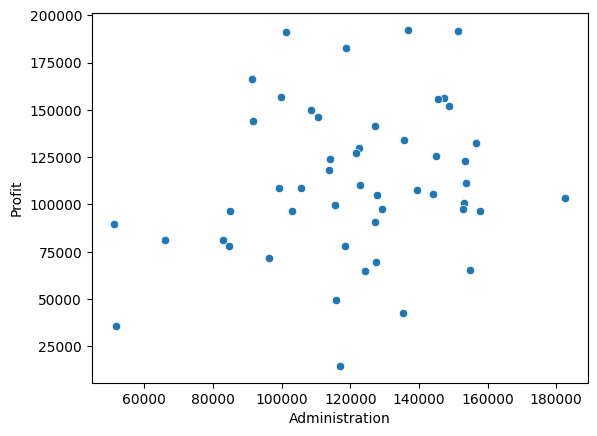

In [ ]:
sns.scatterplot(x='Administration', y='Profit', data=df)

### Hypothesis testing


Check if there is any correlation between R&D and Profit

In [6]:
!pip install -q scipy

In [16]:
from scipy.stats import pearsonr

SL = 0.05
corr, pvalue = pearsonr(df['R&D Spend'], df['Profit'])
if pvalue < SL:
  print('Both are correlated')
  print(f'p-value: {pvalue:.10f}, correlation: {corr:.10f}')
else:
  print('Not correlated')

Both are correlated
p-value: 0.0000000000, correlation: 0.9729004657


In [17]:
corr, pvalue = pearsonr(df['Marketing Spend'], df['Profit'])
if pvalue < SL:
  print('Both are correlated')
  print(f'p-value: {pvalue:.10f}, correlation: {corr:.10f}')
else:
  print('Not correlated')

Both are correlated
p-value: 0.0000000004, correlation: 0.7477657217


In [18]:
corr, pvalue = pearsonr(df['Administration'], df['Profit'])
if pvalue < SL:
  print('Both are correlated')
  print(f'p-value: {pvalue:.10f}, correlation: {corr:.10f}')
else:
  print('Not correlated')

Not correlated


Normality Test

In [22]:
from scipy.stats import shapiro

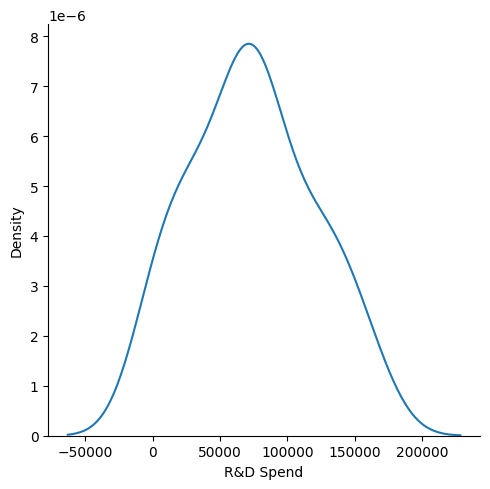

In [20]:
sns.displot(df['R&D Spend'], kind='kde')

In [30]:
SL = 0.1
wvalue, pvalue = shapiro(df['R&D Spend'])
if pvalue > SL:
  print('Normal')
else:
  print('Not normal')

Normal


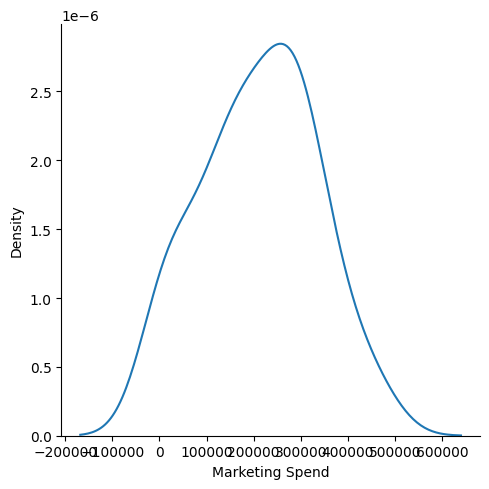

In [26]:
sns.displot(df['Marketing Spend'], kind='kde')

In [31]:
wvalue, pvalue = shapiro(df['Marketing Spend'])
if pvalue > SL:
  print('Normal')
else:
  print('Not normal')

Normal


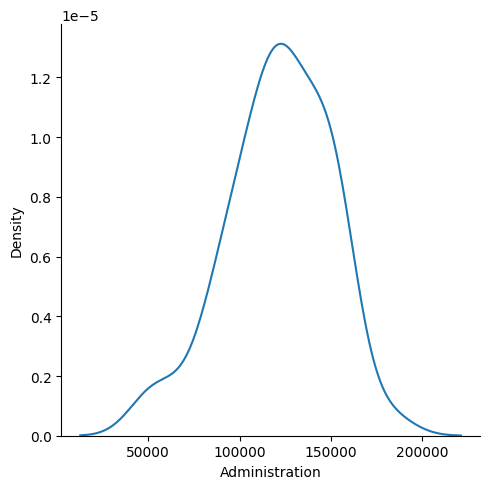

In [32]:
sns.displot(df['Administration'], kind='kde')

In [34]:
corr, pvalue = shapiro(df['Administration'])
if pvalue > SL:
  print('Normal')
  print(pvalue)
else:
  print('Not normal')

Normal
0.23661510867025154
